c:\Users\pinte\miniconda3\envs\cv_pipeline_rl\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\pinte\miniconda3\envs\cv_pipeline_rl\Lib\site-packages\stable_baselines3\common\save_util.py:166: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Model loaded from final_model_2d.zip
Observation space: Box(-1.0, 1.0, (6,), float32)
Action space: Box(-1.0, 1.0, (2,), float32)
Moving to fixed Z=0.125...
  Reached Z=0.1240
Testing 5 plant coordinates


Plant 1: X=0.1000, Y=0.0900
 Step 0 | Distance: 27.00mm | Pos: [0.0730, 0.0895] | Action: [0.91, 0.01]
 Step 200 | Distance: 0.61mm | Pos: [0.0999, 0.0906] | Action: [-0.33, 0.01]
 Step 400 | Distance: 0.61mm | Pos: [0.0999, 0.0906] | Action: [-0.34, 0.01]
 Step 600 | Distance: 0.67mm | Pos: [0.0997, 0.0906] | Action: [-0.13, 0.00]
 Step 800 | Distance: 0.72mm | Pos: [0.0996, 0.0906] | Action: [0.42, -0.00]
 Plant 1 not reached (final distance: 0.61mm)

Plant 2: X=0.1500, Y=0.1000
 Step 0 | Distance: 51.05mm | Pos: [0.0998, 0.0907] | Action: [0.79, 0.44]
 Step 200 | Distance: 0.71mm | Pos: [0.1499, 0.1007] | Action: [0.35, -0.01]
 Step 400 | Distance: 0.71mm | Pos: [0.1501, 0.1007] | Action: [-0.13, 0.00]
 Step 600 | Distance: 0.73mm | Pos: [0.1502, 0.1007] | Action: [-0.32, 0.00]
 S

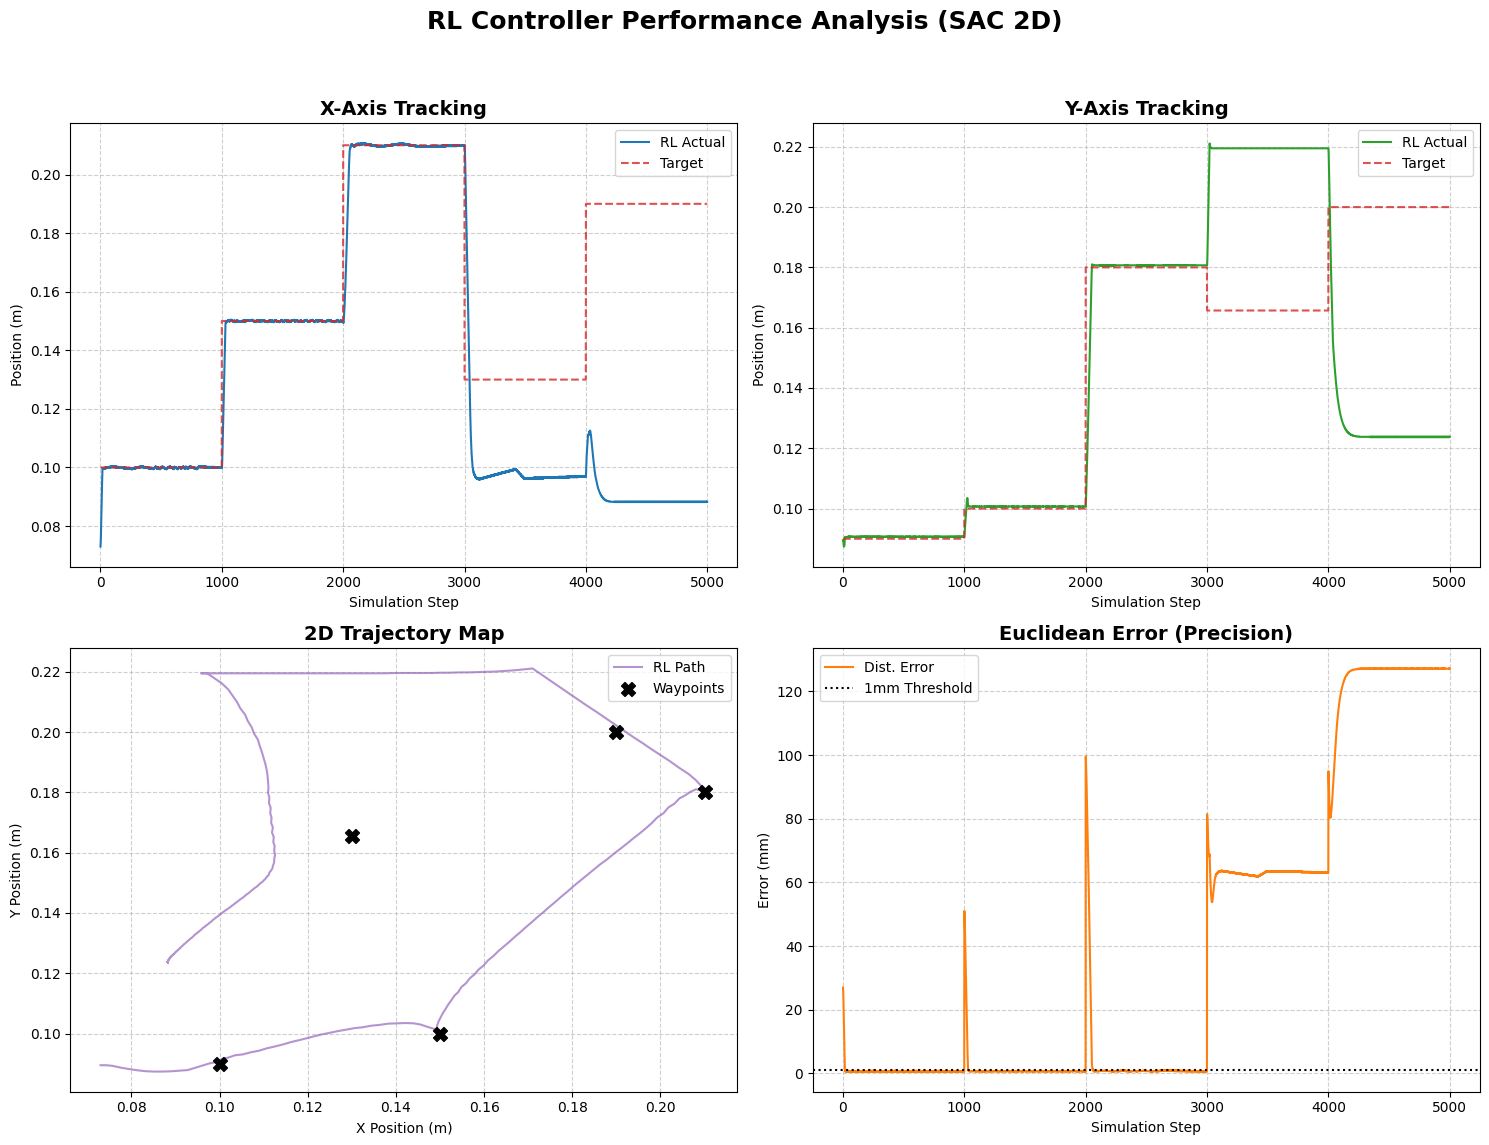


Detailed RL plot saved as 'rl_performance_report.png'


In [1]:
from sim_class import Simulation
from stable_baselines3 import SAC
import numpy as np
import matplotlib.pyplot as plt

sim = Simulation(num_agents=1)
image_path = sim.get_plate_image()

"""
Test script for 2D RL controller (fixed Z=0.125).
Testing with plant coordinates from pipeline.
"""

# Reset and get robot ID
initial_states = sim.reset()
robot_id = next(iter(initial_states))
robot_id_num = int(robot_id.split('_')[-1])

# Load trained 2D model
MODEL_PATH = "final_model_2d.zip" 
model = SAC.load(MODEL_PATH)
print(f"Model loaded from {MODEL_PATH}")
print(f"Observation space: {model.observation_space}")
print(f"Action space: {model.action_space}")            

# Normalization bounds (must match 2D wrapper)
PIPETTE_X_MIN, PIPETTE_X_MAX = -0.187, 0.253
PIPETTE_Y_MIN, PIPETTE_Y_MAX = -0.1705, 0.2195
MAX_VELOCITY = 1.0
FIXED_Z = 0.125
VELOCITY_SCALE = 0.5

OBS_LOW = np.array([
    PIPETTE_X_MIN, PIPETTE_Y_MIN,
    -MAX_VELOCITY, -MAX_VELOCITY,
    PIPETTE_X_MIN, PIPETTE_Y_MIN
], dtype=np.float32)

OBS_HIGH = np.array([
    PIPETTE_X_MAX, PIPETTE_Y_MAX,
    MAX_VELOCITY, MAX_VELOCITY,
    PIPETTE_X_MAX, PIPETTE_Y_MAX
], dtype=np.float32)


def normalize_obs(obs):
    """Normalize observation to [-1, 1] range."""
    return (2.0 * (obs - OBS_LOW) / (OBS_HIGH - OBS_LOW) - 1.0).astype(np.float32)


def move_to_fixed_z(sim, robot_id_num, target_z=FIXED_Z):
    """Move pipette to fixed Z height."""
    print(f"Moving to fixed Z={target_z}...")
    for _ in range(500):
        current_pos = sim.get_pipette_position(robotId=robot_id_num)
        z_error = target_z - current_pos[2]
        
        if abs(z_error) < 0.001:
            print(f"  Reached Z={current_pos[2]:.4f}")
            break
        
        z_vel = np.clip(z_error * 10.0, -1.0, 1.0) * VELOCITY_SCALE
        sim.run([[0.0, 0.0, float(z_vel), 0]], num_steps=1)


def get_observation_2d(sim, robot_id, goal_xy):
    """Build 6D observation for 2D controller."""
    states = sim.get_states()
    robot_state = states[robot_id]
    
    pipette_pos = np.array(robot_state["pipette_position"], dtype=np.float32)
    joint_states = robot_state["joint_states"]
    
    velocity_xy = np.array([
        -joint_states["joint_0"]["velocity"],
        -joint_states["joint_1"]["velocity"],
    ], dtype=np.float32)
    
    # Clip values
    pos_xy = np.clip(pipette_pos[:2], OBS_LOW[:2], OBS_HIGH[:2])
    velocity_xy = np.clip(velocity_xy, -MAX_VELOCITY, MAX_VELOCITY)
    goal_xy_clipped = np.clip(goal_xy, OBS_LOW[4:6], OBS_HIGH[4:6])
    
    obs = np.concatenate([
        pos_xy,           # X, Y position
        velocity_xy,      # X, Y velocity
        goal_xy_clipped   # X, Y goal
    ]).astype(np.float32)
    
    return obs, pipette_pos

waypoint_array = np.array([
  [0.10, 0.09, 0.1250],
  [0.15, 0.10, 0.1250],
  [0.21, 0.18, 0.1250],
  [0.13, 0.1657, 0.1250],
  [0.19, 0.20, 0.1250],
])

# Reset and move to fixed Z
reset_states = sim.reset()
robot_id = next(iter(reset_states))
robot_id_num = int(robot_id.split('_')[-1])
move_to_fixed_z(sim, robot_id_num, FIXED_Z)

# Tracking
all_positions = []
all_targets = []
all_errors = []
results = []


print(f"Testing {len(waypoint_array)} plant coordinates")
print("="*60 + "\n")

for plant_idx, waypoint in enumerate(waypoint_array):
    target_xy = waypoint[:2].astype(np.float32)  # Only X, Y
    steps_at_target = 0
    
    print(f"\nPlant {plant_idx + 1}: X={target_xy[0]:.4f}, Y={target_xy[1]:.4f}")
    
    for i in range(1000):
        # Get 6D observation
        obs_raw, pipette_pos = get_observation_2d(sim, robot_id, target_xy)
        obs_normalized = normalize_obs(obs_raw)
        
        # Get 2D action from model
        action, _ = model.predict(np.array(obs_normalized, dtype=np.float32), deterministic=True)
        
        # Calculate 2D error
        error_xy = target_xy - pipette_pos[:2]
        distance = np.linalg.norm(error_xy)
        
        # Track
        all_positions.append(pipette_pos.copy())
        all_targets.append(waypoint.copy())
        all_errors.append(distance)

        dispensed = False
        
        # Check success (1mm threshold)
        if distance < 0.0001:
            steps_at_target += 1
            if steps_at_target > 10:
                print(f" Plant {plant_idx + 1} reached at step {i} (distance: {distance}mm)")
                results.append({"plant": plant_idx + 1, "success": True, "steps": i, "distance_mm": distance})
                if not dispensed:
                        # Dispense one drop
                        dispense_action = [[0.0, 0.0, 0.0, 1]]
                        sim.run(dispense_action, num_steps=1)
                        
                        wait_action = [[0.0, 0.0, 0.0, 0]]
                        sim.run(wait_action, num_steps=100)  
                        dispensed = True
                break
        else:
            steps_at_target = 0
        
        # Apply 2D action (Z velocity = 0)
        scaled_action = action * VELOCITY_SCALE
        sim_action = [[float(scaled_action[0]), float(scaled_action[1]), 0.0, 0]]
        sim.run(sim_action, num_steps=1)
        
        if i % 200 == 0:
            print(f" Step {i} | Distance: {distance*1000:.2f}mm | Pos: [{pipette_pos[0]:.4f}, {pipette_pos[1]:.4f}] | Action: [{action[0]:.2f}, {action[1]:.2f}]")
    
    if steps_at_target <= 10:
        print(f" Plant {plant_idx + 1} not reached (final distance: {distance*1000:.2f}mm)")
        results.append({"plant": plant_idx + 1, "success": False, "steps": 1000, "distance_mm": distance*1000})


final_pos = sim.get_pipette_position(robotId=robot_id_num)
print(f"\nFinal Position: {final_pos}")

#PLOTTING
import matplotlib.pyplot as plt

all_positions = np.array(all_positions)
all_targets = np.array(all_targets)
all_errors = np.array(all_errors)

# Create a 2x2 grid for a comprehensive view
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. X-Axis Tracking (Time Series)
axes[0, 0].plot(all_positions[:, 0], label='RL Actual', color='#1f77b4', linewidth=1.5)
axes[0, 0].plot(all_targets[:, 0], '--', label='Target', color='#d62728', alpha=0.8)
axes[0, 0].set_title('X-Axis Tracking', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Position (m)')
axes[0, 0].set_xlabel('Simulation Step')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Y-Axis Tracking (Time Series)
axes[0, 1].plot(all_positions[:, 1], label='RL Actual', color='#2ca02c', linewidth=1.5)
axes[0, 1].plot(all_targets[:, 1], '--', label='Target', color='#d62728', alpha=0.8)
axes[0, 1].set_title('Y-Axis Tracking', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Position (m)')
axes[0, 1].set_xlabel('Simulation Step')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 3. 2D Trajectory Map (XY Path)
axes[1, 0].plot(all_positions[:, 0], all_positions[:, 1], label='RL Path', color='#9467bd', alpha=0.7)
# Mark the target waypoints specifically
unique_targets = []
for t in all_targets:
    if len(unique_targets) == 0 or not np.array_equal(t, unique_targets[-1]):
        unique_targets.append(t)
unique_targets = np.array(unique_targets)
axes[1, 0].scatter(unique_targets[:, 0], unique_targets[:, 1], c='black', marker='X', s=100, label='Waypoints', zorder=5)
axes[1, 0].set_title('2D Trajectory Map', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('X Position (m)')
axes[1, 0].set_ylabel('Y Position (m)')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# 4. Euclidean Distance Error (Precision)
# Converting to mm for better readability
axes[1, 1].plot(all_errors * 1000, label='Dist. Error', color='#ff7f0e')
axes[1, 1].axhline(y=1.0, color='black', linestyle=':', label='1mm Threshold')
axes[1, 1].set_title('Euclidean Error (Precision)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Error (mm)')
axes[1, 1].set_xlabel('Simulation Step')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Main Title for the RL Model report
plt.suptitle('RL Controller Performance Analysis (SAC 2D)', fontsize=18, y=0.98, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('rl_performance_report.png', dpi=150)
plt.show()

print("\nDetailed RL plot saved as 'rl_performance_report.png'")